## 0. Environment

In [ ]:
# ==============================
# Initialization: Environment & Backends
# ==============================

# If needed:
# %pip install -q accelerate>=0.34.2 safetensors>=0.4.3 sentencepiece packaging

# Uncomment and replace with own private key if using gpt
# os.environ["LLM_BACKEND"] = "openai"
# os.environ["OPENAI_API_KEY"] = "Your_key"
# os.environ["GPT5_MODEL"] = "gpt-5"

import os, re, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any
from sklearn.metrics import accuracy_score, f1_score

# ---- Repro ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---- Device & backend ----
device  = "cuda" if torch.cuda.is_available() else "cpu"
BACKEND = os.environ.get("LLM_BACKEND", "hf")  # "hf" or "openai"

# ---- Models ----
HF_MODEL   = os.environ.get("HF_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
GPT5_MODEL = os.environ.get("GPT5_MODEL", "gpt-5")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")

print(f"Device: {device}")
print(f"Backend: {BACKEND}")
print(f"HF Model: {HF_MODEL if BACKEND=='hf' else 'N/A'}")
print(f"GPT-5 Model: {GPT5_MODEL if BACKEND=='openai' else 'N/A'}")

ATTN_IMPL = "eager"  # safe default for older GPUs

if BACKEND == "hf":
    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

    # Load config first to pin attention implementation
    config = AutoConfig.from_pretrained(HF_MODEL)
    try:
        # Not every config exposes this, so guard it
        setattr(config, "attn_implementation", ATTN_IMPL)
    except Exception:
        pass

    tokenizer = AutoTokenizer.from_pretrained(HF_MODEL, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(
        HF_MODEL,
        config=config,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=False,   # flip to True only if your model requires it
    )
    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    model.to(device)
    model.eval()
    print("✅ Loaded HF model (fp16 on CUDA if available), attention=eager.")
else:
    import openai
    if not OPENAI_API_KEY:
        raise EnvironmentError("OPENAI_API_KEY not set; export it to use the OpenAI backend.")
    openai.api_key = OPENAI_API_KEY
    print(f"✅ OpenAI backend ready (model={GPT5_MODEL})")


Device: cuda
Backend: openai
HF Model: N/A
GPT-5 Model: gpt-5
✅ OpenAI backend ready (model=gpt-5)


## 1. Task Generator

In [30]:
@dataclass
class ClfTask:
    W: np.ndarray
    X: np.ndarray
    y: np.ndarray
    x_test: np.ndarray
    y_test: int

def sample_clf_task(d: int = 10, N: Optional[int] = None, alpha: float = 1.0) -> ClfTask:
    if N is None: N = 2*d + 1
    W = np.random.randn(d)
    X = np.random.uniform(-alpha, alpha, size=(N, d))
    y = np.sign(X @ W).astype(int); y[y==0] = 1
    x_t = np.random.uniform(-alpha, alpha, size=(d,))
    y_t = int(np.sign(x_t @ W) or 1)
    return ClfTask(W, X, y, x_t, y_t)

## 2. GD-1 Baseline

In [31]:
def gd1_clf_predict(X: np.ndarray, y: np.ndarray, x_test: np.ndarray, eta: float = 1.0) -> int:
    N = X.shape[0]
    W1 = (0.5 * eta / N) * (y[:, None] * X).sum(axis=0)
    return 1 if float(W1 @ x_test) >= 0 else -1

## 3. Prompt Construction

In [32]:
FLOAT_RE = re.compile(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?")
TOKEN_RE = re.compile(r'(?<!\d)[\+\-]?1(?!\d)')  # standalone -1, +1, or 1

def fmtv(x, digits=5):
    return ", ".join(f"{v:.{digits}f}" for v in x.tolist())

def build_prompt(t: ClfTask, digits: int = 5):
    ctx = "\n".join([f"({fmtv(t.X[i],digits)}) -> {int(t.y[i])}" for i in range(t.X.shape[0])])
    xs  = fmtv(t.x_test,digits)
    return (
        "You are solving a noiseless linear classification task: y = sign(W · x).\n"
        "Given training pairs (x -> y) with y in {-1, +1}, predict y for x_test.\n\n"
        f"{ctx}\n\nx_test = [{xs}]\n"
        "Respond with a single integer: -1 or +1 (no text, no punctuation)."
    )

## 4. Prediction Wrappers

In [33]:
@torch.no_grad()
def hf_predict(prompt: str, max_new_tokens: int = 8):
    """
    HF (LLaMA) inference with safe decoding and fallback handling.
    """
    try:
        inp = tokenizer(prompt, return_tensors="pt").to(device)
        out = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1e-5,       # deterministic-ish; safe for HF
            top_p=1.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=getattr(tokenizer, "pad_token_id", tokenizer.eos_token_id),
            use_cache=True,
        )
        gen = out[0][inp["input_ids"].shape[1]:]
        txt = tokenizer.decode(gen, skip_special_tokens=True).strip() if gen.numel() > 0 else ""
    except Exception as e:
        # Conservative fallback: return empty so caller can skip this task
        txt = ""
    return parse_label(txt)


def openai_predict(prompt: str, model_name: Optional[str] = None):
    """
    GPT API inference
    """
    if model_name is None:
        model_name = "gpt-5"
    client = OpenAI()
    response = client.responses.create(
        model="gpt-5",
        instructions="You are a precise classifier. Reply with exactly one token: -1 or +1.",
        input=prompt
    )
    return int(response.output_text)

def llm_predict(prompt: str):
    """
    Route to the active backend.
    """
    return hf_predict(prompt) if BACKEND == "hf" else openai_predict(prompt)


## 5. Evaluation

In [34]:
def eval_clf_suite(n_tasks: int=10, d: int=10, N: Optional[int]=None, alpha: float=1.0, eta: float=1.0):
    y_true, y_llm, y_gd1 = [], [], []
    for _ in range(n_tasks):
        t = sample_clf_task(d,N,alpha)
        yhat = llm_predict(build_prompt(t))
        if yhat is None: continue
        yhat_gd1 = gd1_clf_predict(t.X,t.y,t.x_test,eta)
        y_true.append(t.y_test); y_llm.append(yhat); y_gd1.append(yhat_gd1)
    return {
        "evaluated": len(y_true),
        "acc_llm": accuracy_score(y_true,y_llm) if y_true else float("nan"),
        "acc_gd1": accuracy_score(y_true,y_gd1) if y_true else float("nan"),
        "f1_llm":  f1_score(y_true,y_llm) if y_true else float("nan"),
    }

## 6. Run + Plot

Running backend=openai, d=10, N=21
α=0.5 → LLM acc=0.800, GD-1 acc=0.800
α=1.0 → LLM acc=0.700, GD-1 acc=0.700
α=1.5 → LLM acc=0.800, GD-1 acc=0.800
α=2.0 → LLM acc=0.900, GD-1 acc=0.900


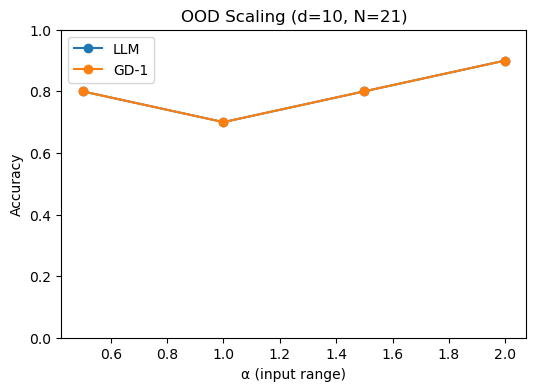

In [35]:
D = int(os.environ.get("D_DIM","10"))
N = 2*D + 1
ETA = 1.0
ALPHAS = [0.5, 1.0, 1.5, 2.0]

print(f"Running backend={BACKEND}, d={D}, N={N}")
results = []
for a in ALPHAS:
    r = eval_clf_suite(n_tasks=10, d=D, N=N, alpha=a, eta=ETA)
    results.append(r)
    print(f"α={a:.1f} → LLM acc={r['acc_llm']:.3f}, GD-1 acc={r['acc_gd1']:.3f}")

plt.figure(figsize=(6,4))
plt.plot(ALPHAS, [r["acc_llm"] for r in results], marker="o", label="LLM", linestyle="--")
plt.plot(ALPHAS, [r["acc_gd1"] for r in results], marker="o", label="GD-1")
plt.xlabel("α (input range)")
plt.ylabel("Accuracy")
plt.title(f"OOD Scaling (d={D}, N={N})")
plt.legend(); plt.ylim(0,1); plt.show()